In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

C:\Users\Faisal\AppData\Local\Temp\ipykernel_16880\45199494.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/cleaned_data.csv")


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    524878 non-null  object 
 1   StockCode    524878 non-null  object 
 2   Description  524878 non-null  object 
 3   Quantity     524878 non-null  int64  
 4   InvoiceDate  524878 non-null  object 
 5   UnitPrice    524878 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      524878 non-null  object 
 8   revenue      524878 non-null  float64
 9   Revenue      524878 non-null  float64
dtypes: float64(4), int64(1), object(5)
memory usage: 40.0+ MB


In [6]:
df['CustomerID']=df['CustomerID'].astype("Int64")

In [7]:
df['CustomerID'].dtype

Int64Dtype()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    524878 non-null  object 
 1   StockCode    524878 non-null  object 
 2   Description  524878 non-null  object 
 3   Quantity     524878 non-null  int64  
 4   InvoiceDate  524878 non-null  object 
 5   UnitPrice    524878 non-null  float64
 6   CustomerID   392692 non-null  Int64  
 7   Country      524878 non-null  object 
 8   revenue      524878 non-null  float64
 9   Revenue      524878 non-null  float64
dtypes: Int64(1), float64(3), int64(1), object(5)
memory usage: 40.5+ MB


In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [11]:
df['year'] = df['InvoiceDate'].dt.year
df['month'] = df['InvoiceDate'].dt.month

In [12]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue,Revenue,year,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,15.30,2010,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,20.34,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,22.00,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,20.34,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,20.34,2010,12


In [13]:
df.drop("revenue",axis=1,inplace=True)

In [14]:
df['StockCode'].nunique()

3922

In [15]:
df['CustomerID'].nunique()

4338

In [16]:
df['Country'].nunique()

38

In [17]:
df['InvoiceNo'].nunique()

19962

In [18]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
year                0
month               0
dtype: int64

In [19]:
print(f"Total revenue: £{df['Revenue'].sum():.2f}")

Total revenue: £10642110.80


In [20]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,year,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12


In [21]:
df[['Quantity','UnitPrice','Revenue']].describe()

,Quantity,UnitPrice,Revenue
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


In [26]:
df[df['Quantity'] == 80995]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,year,month
523404,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.6,2011,12


In [31]:
df.drop(df[df['Quantity'] == 80995].index, inplace=True)

In [32]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,year,month
count,524877.000000,524877,524877.000000,392691.0,524877.000000,524877.000000,524877.000000
mean,10.462308,2011-07-04 15:29:50.351567872,3.922576,15287.840916,19.954468,2010.921904,7.552228
min,1.000000,2010-12-01 08:26:00,0.001000,12346.0,0.001000,2010.000000,1.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.0,3.900000,2011.000000,5.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.0,9.920000,2011.000000,8.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.0,17.700000,2011.000000,11.000000
max,74215.000000,2011-12-09 12:50:00,13541.330000,18287.0,77183.600000,2011.000000,12.000000
std,109.216276,NaN,36.093062,1713.540734,140.558567,0.268323,3.508162


In [47]:
total_revenue = df['Revenue'].sum()

In [52]:
top_5_countries = (df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5))
top_5_percentage = (top_5_countries/total_revenue)*100

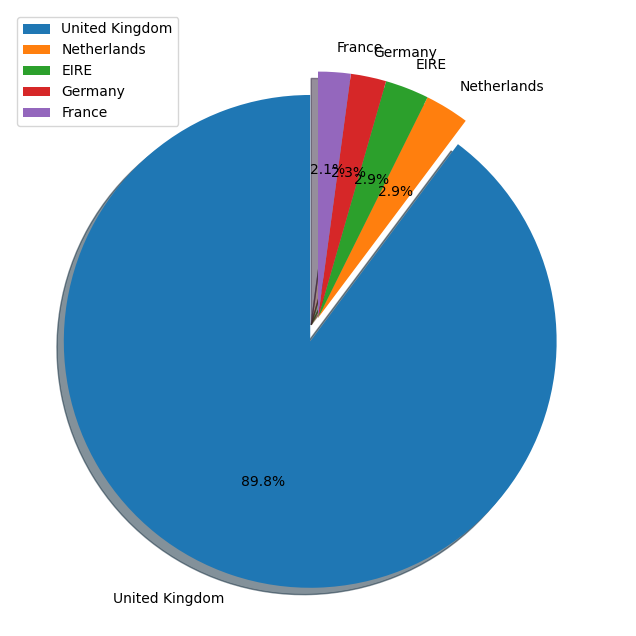

In [55]:
plt.figure(figsize=(8, 8))
myexplode = (0.1, 0, 0, 0, 0)
plt.pie(top_5_percentage, labels=top_5_percentage.index,autopct='%1.1f%%', startangle=90, explode=myexplode,shadow=True)
plt.legend()
plt.show()

## Revenue by month

In [57]:
monthly_revenue = (df.groupby(['year','month'])['Revenue'].sum().reset_index())
monthly_revenue

,year,month,Revenue
0,2010,12,821452.730
1,2011,1,689811.610
2,2011,2,522545.560
3,2011,3,716215.260
4,2011,4,536968.491
5,2011,5,769296.610
6,2011,6,760547.010
7,2011,7,718076.121
8,2011,8,757841.380
9,2011,9,1056435.192


In [67]:
monthly_revenue['year_month'] = monthly_revenue['year'].astype(str) + '-' + monthly_revenue['month'].astype(str)
monthly_revenue

,year,month,Revenue,year_month
0,2010,12,821452.730,2010-12
1,2011,1,689811.610,2011-1
2,2011,2,522545.560,2011-2
3,2011,3,716215.260,2011-3
4,2011,4,536968.491,2011-4
5,2011,5,769296.610,2011-5
6,2011,6,760547.010,2011-6
7,2011,7,718076.121,2011-7
8,2011,8,757841.380,2011-8
9,2011,9,1056435.192,2011-9


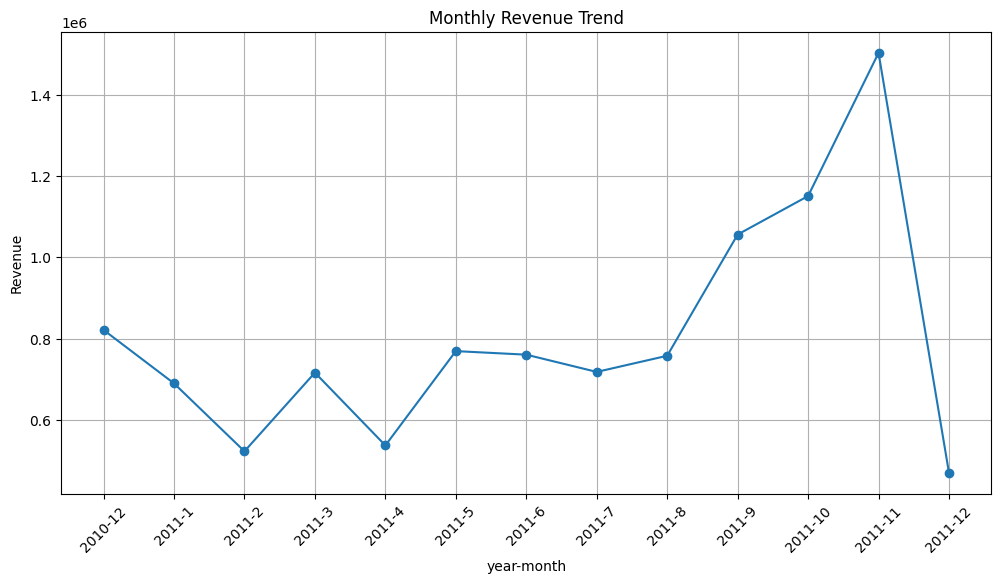

In [72]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['year_month'],monthly_revenue['Revenue'],marker='o')
plt.xlabel('year-month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## top 10 product by revenue


In [74]:
top_10_products = (df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10))
top_10_products


Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
Name: Revenue, dtype: float64

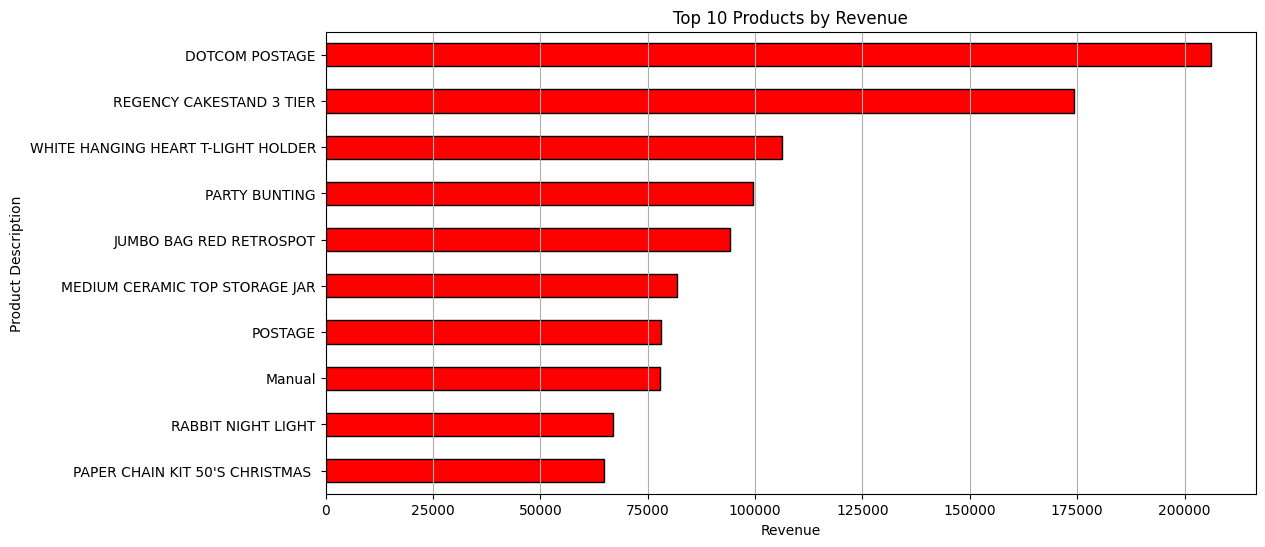

In [81]:
plt.figure(figsize=(12, 6))

top_10_products.sort_values().plot(kind='barh', color='red', edgecolor='black')
plt.xlabel('Revenue')
plt.ylabel('Product Description')
plt.title('Top 10 Products by Revenue')
plt.grid(axis='x')
plt.show()

## Top 10 product by quantity

In [82]:
top_10_pro_by_quan = (df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10))



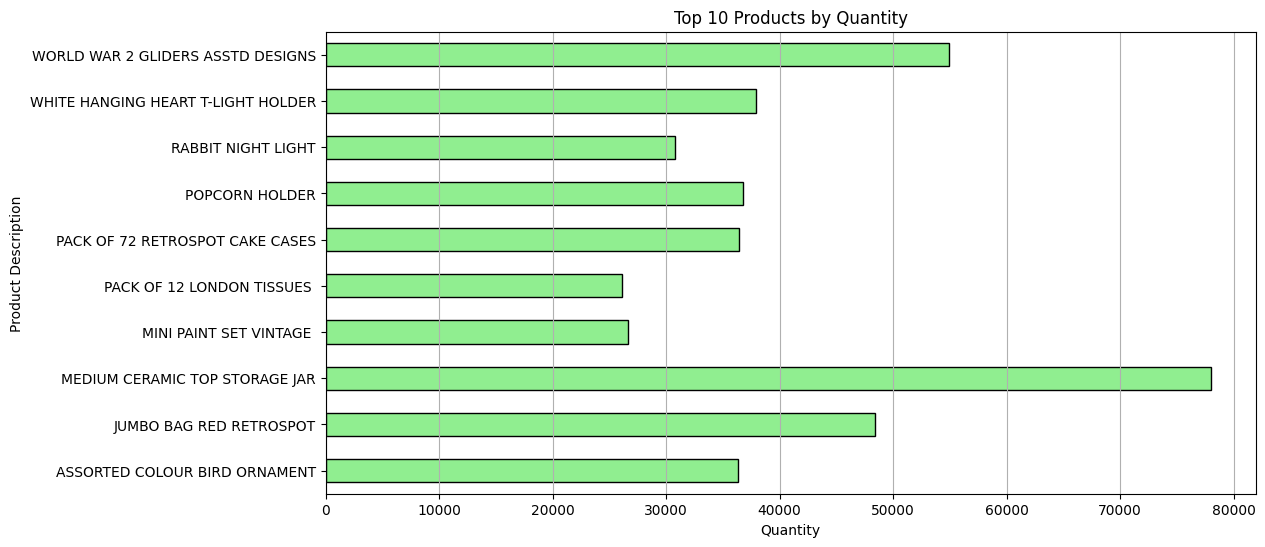

In [99]:
plt.figure(figsize=(12,6))
top_10_pro_by_quan.sort_index().plot(kind='barh', color ='lightgreen', edgecolor='black')
plt.xlabel('Quantity')
plt.ylabel('Product Description')
plt.title('Top 10 Products by Quantity')
plt.grid(axis='x')
plt.show()

# Customer Analysis

In [87]:
print(f'Total Customers : {df['CustomerID'].nunique()}')

Total Customers : 4338


### Top 10 customer by revenue


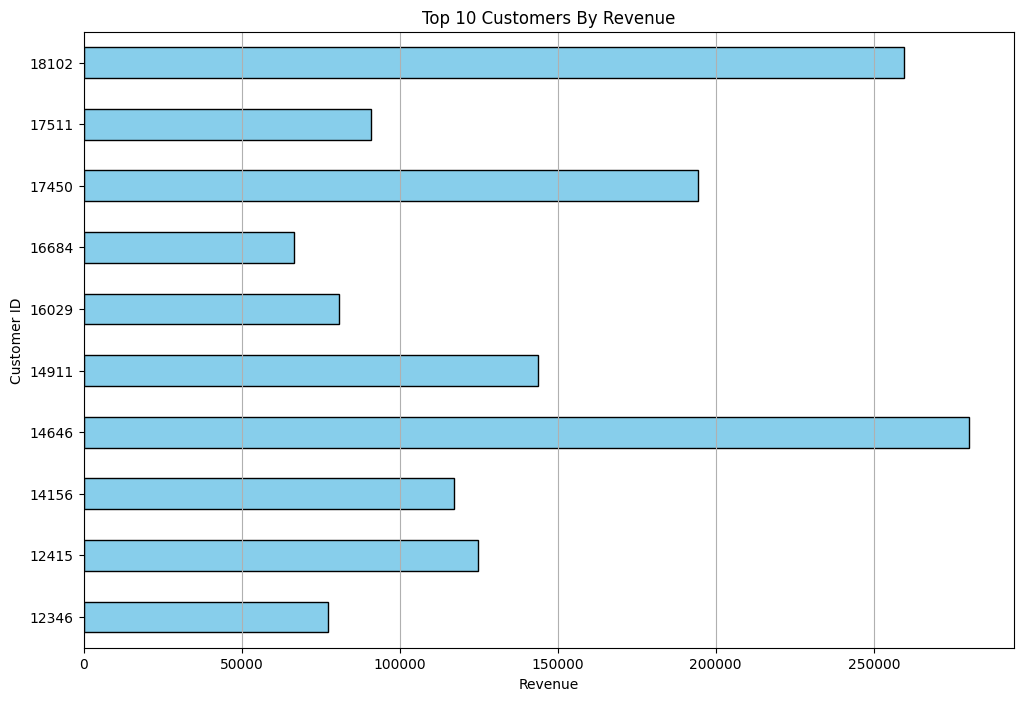

In [91]:
top_10_customer = (df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,8))
top_10_customer.sort_index().plot(kind = 'barh',color = 'skyblue', edgecolor = 'black')
plt.xlabel('Revenue')
plt.ylabel('Customer ID')
plt.title('Top 10 Customers By Revenue')
plt.grid(axis='x')
plt.show()

### top 10 Customer by Quantity

In [93]:
top_10_cus_by_quan = (df.groupby('CustomerID')['Quantity'].sum().sort_values(ascending=False).head(10))

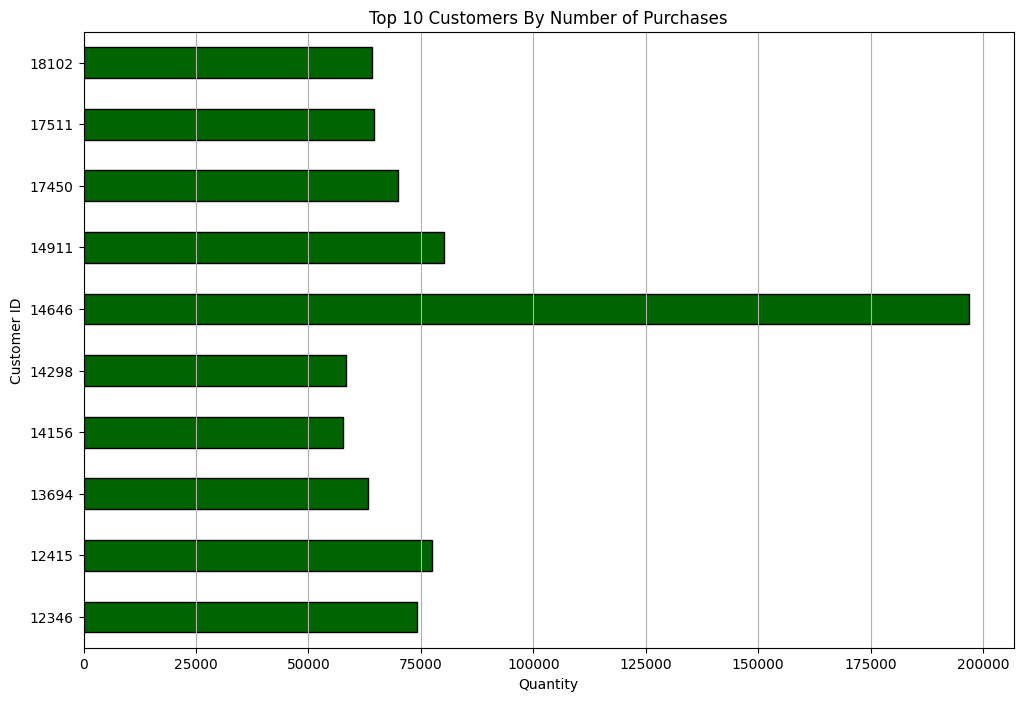

In [96]:
plt.figure(figsize=(12,8))

top_10_cus_by_quan.sort_index().plot(kind = 'barh',color = 'darkgreen', edgecolor = 'black')
plt.xlabel('Quantity')
plt.ylabel('Customer ID')
plt.title('Top 10 Customers By Number of Purchases')
plt.grid(axis='x')
plt.show()

## Outlier Analysis


In [100]:
print("Quantity > 1000:", (df['Quantity'] > 1000).sum())
print("UnitPrice > 100:", (df['UnitPrice'] > 100).sum())
print("Revenue > 1000:", (df['Revenue'] > 1000).sum())

Quantity > 1000: 105
UnitPrice > 100: 811
Revenue > 1000: 387


In [101]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'year', 'month'],
      dtype='object')

In [102]:
df.nlargest(20,'Quantity')[['InvoiceNo','StockCode','Description','Quantity','UnitPrice','Revenue']]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue
59649,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60
408238,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00
199399,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00
94208,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92
262196,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16
50902,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
155191,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
420062,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00
4784,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40
281996,562439,84879,ASSORTED COLOUR BIRD ORNAMENT,2880,1.45,4176.00


In [106]:
df.nlargest(20, 'UnitPrice')[
    ['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'Revenue', 'Country']
]

,InvoiceNo,Description,Quantity,UnitPrice,Revenue,Country
14456,537632,AMAZON FEE,1,13541.33,13541.33,United Kingdom
290506,A563185,Adjust bad debt,1,11062.06,11062.06,United Kingdom
167609,551697,POSTAGE,1,8142.75,8142.75,United Kingdom
288286,562955,DOTCOM POSTAGE,1,4505.17,4505.17,United Kingdom
259507,560373,Manual,1,4287.63,4287.63,United Kingdom
408928,573077,Manual,1,4161.06,4161.06,France
408952,573080,Manual,1,4161.06,4161.06,France
393568,571751,Manual,1,3949.32,3949.32,Singapore
363041,569382,Manual,1,3155.95,3155.95,United Kingdom
337159,567353,Manual,1,2653.95,2653.95,Hong Kong


The UnitPrice column contains some unusually high values. Most of these are related to fees, postage, bad debt adjustments, and manual transactions rather than regular products. Since these values represent actual recorded business transactions and are not clearly data errors, they were kept in the dataset for further analysis.


In [107]:
df.nlargest(20, 'Revenue')[
    ['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'Revenue', 'Country']
]

,InvoiceNo,Description,Quantity,UnitPrice,Revenue,Country
59649,541431,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,United Kingdom
215474,556444,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,United Kingdom
14456,537632,AMAZON FEE,1,13541.33,13541.33,United Kingdom
290506,A563185,Adjust bad debt,1,11062.06,11062.06,United Kingdom
167609,551697,POSTAGE,1,8142.75,8142.75,United Kingdom
337516,567423,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,United Kingdom
50902,540815,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
155191,550461,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
408207,573003,RABBIT NIGHT LIGHT,2400,2.08,4992.00,Netherlands
50900,540815,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.55,4921.50,United Kingdom


The Revenue column contains some unusually high values, These mainly come from large volume product purchases as well as fees, postage, and manual business transactions. Since these records represent actual transactions in the dataset and there is no clear evidence that they are incorrect, the outliers were retained for further analysis.


### Correlation Analysis

In [108]:
correlation = df[['Quantity','UnitPrice','Revenue']].corr()

In [109]:
correlation

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.005349,0.816747
UnitPrice,-0.005349,1.000000,0.265668
Revenue,0.816747,0.265668,1.000000


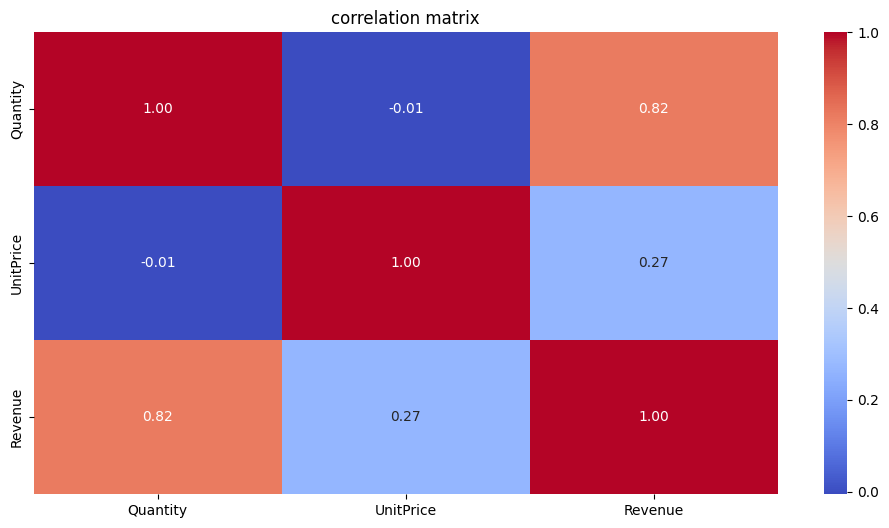

In [111]:
plt.figure(figsize=(12,6))
sns.heatmap(correlation,annot=True, cmap='coolwarm', fmt=".2f")
plt.title('correlation matrix')
plt.show()

### These are Basic KPIs

In [113]:
print("Total Revenue:", df['Revenue'].sum())
print("Total Orders:", df['InvoiceNo'].nunique())
print("Unique Customers:", df['CustomerID'].nunique())
print("Unique Products:", df['Description'].nunique())
print("Countries:", df['Country'].nunique())

Total Revenue: 10473641.204
Total Orders: 19961
Unique Customers: 4338
Unique Products: 4025
Countries: 38


### Business Insights

* The dataset has a total revenue of about **£10.47 million** from **19,961 orders**.
* There are **4,338 different customers** in the dataset.
* The dataset has **4,025 different products**, which means the business sells many types of products.
* The orders come from **38 different countries**, so the business has customers from different parts of the world.
* Revenue is strongly related to the quantity sold. This means selling more products usually leads to more revenue.
* Some very high values were found in Quantity, UnitPrice, and Revenue. These values were kept because they look like real business transactions and not clear mistakes.
* Some of the highest-value transactions are from large product orders, while others are related to **postage, fees, and manual entries**.
